<a href="https://colab.research.google.com/github/hiranshree/AIML/blob/main/preprocessing_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import os

# ==========================================
# 1. FORMATTING
# ==========================================
def preprocess_formatting(df):
    """Initial cleanup: standardize timestamps and ensure numeric data."""
    if 'Timestamp' not in df.columns:
        df = df.rename(columns={df.columns[0]: 'Timestamp'})
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
    df = df.dropna(subset=['Timestamp']).drop_duplicates(subset=['Timestamp'])
    df = df.set_index('Timestamp').sort_index()
    df = df.apply(pd.to_numeric, errors='coerce')
    df = df*0.001  # Convert to kWh
    return df.round(4)

# ==========================================
# 2. INCLUSION LOGIC (With Analysis Report)
# ==========================================
def identify_qualified_buildings(df, threshold=10.0):
    """
    Identifies buildings with a 180-day quality window and generates a report.
    """
    analysis_report = []
    accepted_cols = []

    # 180 days * 24 hours * 4 intervals per hour = 17280
    window_intervals = 17280

    for col in df.columns:
        series = df[col]

        # Identify bad data categories
        is_null = series.isna()
        is_zero = (series == 0)
        m, s = series.mean(), series.std()
        is_outlier = (series > m + 3*s) | (series < m - 3*s)

        # Calculate bad data mask for rolling window check
        bad_mask = is_null | is_zero | is_outlier
        bad_rate_rolling = bad_mask.rolling(window=window_intervals, min_periods=window_intervals).mean() * 100

        # Determine status based on the best available 6-month window
        if (bad_rate_rolling <= threshold).any():
            accepted_cols.append(col)
            status = "ACCEPTED"
            # Get the best error rate found in any window
            best_window_error = round(bad_rate_rolling.min(), 2)
        else:
            status = "REJECTED"
            best_window_error = round(bad_rate_rolling.min(), 2) if not bad_rate_rolling.dropna().empty else 100.0

        # Global stats for the report
        analysis_report.append({
            'Building': col,
            'Missing_%': round((is_null.sum()/len(df))*100, 2),
            'Zeros_%': round((is_zero.sum()/len(df))*100, 2),
            'Outliers_%': round((is_outlier.sum()/len(df))*100, 2),
            'Best_6Mo_Window_Bad_%': best_window_error,
            'Status': status
        })

    return df[accepted_cols], pd.DataFrame(analysis_report)

# ==========================================
# 3. CONSOLIDATED MERGING & SAVING
# ==========================================
def finalize_and_save(df_filtered, base_path='processed'):
    """Resamples and saves the consolidated data."""
    resolutions = {'15min': '15T', '30min': '30T', 'hourly': 'H'}
    # df_cleaned = df_filtered.replace(0, np.nan)

    for label, res_code in resolutions.items():
        # Using sum with min_count=1 to maintain gaps as NaNs
        resampled = df_filtered.resample(res_code).sum(min_count=1).round(4)
        resampled = resampled.dropna(how='all')
        resampled.index.name = 'Timestamp'

        folder = os.path.join(base_path, label)
        os.makedirs(folder, exist_ok=True)

        resampled.to_csv(os.path.join(folder, f"Electricity-{label}.csv"), index=True)
        resampled.to_parquet(os.path.join(folder, f"Electricity-{label}.parquet"), index=True)
        print(f"Saved {label} consolidated file.")

# ==========================================
# MAIN PIPELINE
# ==========================================
def run_pipeline():
    # Load raw data
    if not os.path.exists('/content/final.csv'):
        print("Error: /content/final.csv not found.")
        return

    df_raw = pd.read_csv('/content/final.csv')
    df_fmt = preprocess_formatting(df_raw)

    # Step 2: Filter buildings and generate report
    df_qualified, report = identify_qualified_buildings(df_fmt, threshold=10.0)

    # Save the quality analysis report
    report.to_csv('data_quality_analysis.csv', index=False)
    print("Saved data_quality_analysis.csv")

    if not df_qualified.empty:
        # Step 3: Resample and Save
        finalize_and_save(df_qualified)
        print("\nProcessing complete. Qualified buildings saved.")
    else:
        print("\nNo buildings met the criteria.")

if __name__ == "__main__":
    run_pipeline()

Saved data_quality_analysis.csv


/tmp/ipykernel_11798/280652187.py:77: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  resampled = df_filtered.resample(res_code).sum(min_count=1).round(4)


Saved 15min consolidated file.


/tmp/ipykernel_11798/280652187.py:77: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  resampled = df_filtered.resample(res_code).sum(min_count=1).round(4)


Saved 30min consolidated file.


/tmp/ipykernel_11798/280652187.py:77: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  resampled = df_filtered.resample(res_code).sum(min_count=1).round(4)


Saved hourly consolidated file.

Processing complete. Qualified buildings saved.


In [ ]:
df1 = pd.read_csv('/content/Electricity-15min.csv')
df1.head()

,Timestamp,1st District Headquarters,DC Village,200 I Street Municipal Building,Fort Davis Recreation Center,Kimball Elementary School,Washington Highlands Library,Leckie Elementary School,Simon Elementary School,Southeast Tennis & Learning Center,...,Ross Elementary School,Sasha Bruce Youthwork Inc,Shepard Park Library,Spring Road Community Support Services,Van Ness Elementary School,Washington Seniors Wellness Center,Waterfront Municipal Center East,Waterfront Municipal Center West,H.D. Woodson High School,Youth Services Administration #3
0,2016-01-03 00:00:00,0.0299,0.1022,0.2677,0.0081,0.0105,0.0082,0.0220,0.0227,0.0051,...,NaN,0.0050,0.0084,0.0067,0.0038,0.0045,0.0667,0.1142,0.0674,0.0070
1,2016-01-03 00:15:00,0.0336,0.1084,0.2685,0.0076,0.0107,0.0093,0.0219,0.0189,0.0050,...,NaN,0.0044,0.0087,0.0068,0.0041,0.0046,0.0659,0.1161,0.0674,0.0071
2,2016-01-03 00:30:00,0.0313,0.1040,0.2704,0.0074,0.0109,0.0085,0.0213,0.0221,0.0051,...,NaN,0.0044,0.0083,0.0067,0.0039,0.0044,0.0644,0.1211,0.0676,0.0070
3,2016-01-03 00:45:00,0.0325,0.1036,0.2768,0.0094,0.0105,0.0089,0.0215,0.0222,0.0051,...,NaN,0.0044,0.0083,0.0066,0.0040,0.0048,0.0643,0.1232,0.0666,0.0069
4,2016-01-03 01:00:00,0.0314,0.1109,0.2692,0.0075,0.0107,0.0090,0.0229,0.0212,0.0050,...,NaN,0.0044,0.0084,0.0066,0.0040,0.0044,0.0651,0.1213,0.0666,0.0068


In [ ]:
import pandas as pd
import numpy as np
import os

# ==========================================
# 1. FORMATTING
# ==========================================
def preprocess_formatting(df):
    """Initial cleanup: standardize timestamps and ensure numeric data."""
    if 'Timestamp' not in df.columns:
        df = df.rename(columns={df.columns[0]: 'Timestamp'})
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
    df = df.dropna(subset=['Timestamp']).drop_duplicates(subset=['Timestamp'])
    df = df.set_index('Timestamp').sort_index()
    df = df.apply(pd.to_numeric, errors='coerce')
    df = df*0.001  # Convert to kWh
    return df.round(4)

# ==========================================
# 2. INCLUSION LOGIC (With Analysis Report)
# ==========================================
def identify_qualified_buildings(df, threshold=10.0):
    """
    Identifies buildings with a 180-day quality window and generates a report.
    """
    analysis_report = []
    accepted_cols = []

    # 180 days * 24 hours * 4 intervals per hour = 17280
    window_intervals = 90 * 24 * 4

    for col in df.columns:
        series = df[col]

        # Identify bad data categories
        is_null = series.isna()
        is_zero = (series == 0)
        m, s = series.mean(), series.std()
        is_outlier = (series > m + 3*s) | (series < m - 3*s)

        # Calculate bad data mask for rolling window check
        bad_mask = is_null | is_zero | is_outlier
        bad_rate_rolling = bad_mask.rolling(window=window_intervals, min_periods=window_intervals).mean() * 100

        # Determine status based on the best available 6-month window
        if (bad_rate_rolling <= threshold).any():
            accepted_cols.append(col)
            status = "ACCEPTED"
            # Get the best error rate found in any window
            best_window_error = round(bad_rate_rolling.min(), 2)
        else:
            status = "REJECTED"
            best_window_error = round(bad_rate_rolling.min(), 2) if not bad_rate_rolling.dropna().empty else 100.0

        # Global stats for the report
        analysis_report.append({
            'Building': col,
            'Missing_%': round((is_null.sum()/len(df))*100, 2),
            'Zeros_%': round((is_zero.sum()/len(df))*100, 2),
            'Outliers_%': round((is_outlier.sum()/len(df))*100, 2),
            'Best_6Mo_Window_Bad_%': best_window_error,
            'Status': status
        })

    return df[accepted_cols], pd.DataFrame(analysis_report)

# ==========================================
# 3. CONSOLIDATED MERGING & SAVING
# ==========================================
def finalize_and_save(df_filtered, base_path='./processed/3months'):
    """Resamples and saves the consolidated data."""
    resolutions = {'15min': '15T', '30min': '30T', 'hourly': 'H'}
    # df_cleaned = df_filtered.replace(0, np.nan)

    for label, res_code in resolutions.items():
        # Using sum with min_count=1 to maintain gaps as NaNs
        resampled = df_filtered.resample(res_code).sum(min_count=1).round(4)
        resampled = resampled.dropna(how='all')
        resampled.index.name = 'Timestamp'

        folder = os.path.join(base_path, label)
        os.makedirs(folder, exist_ok=True)

        resampled.to_csv(os.path.join(folder, f"Electricity-{label}.csv"), index=True)
        resampled.to_parquet(os.path.join(folder, f"Electricity-{label}.parquet"), index=True)
        print(f"Saved {label} consolidated file.")

# ==========================================
# MAIN PIPELINE
# ==========================================
def run_pipeline():
    # Load raw data
    if not os.path.exists('/content/final.csv'):
        print("Error: /content/final.csv not found.")
        return

    df_raw = pd.read_csv('/content/final.csv')
    df_fmt = preprocess_formatting(df_raw)

    # Step 2: Filter buildings and generate report
    df_qualified, report = identify_qualified_buildings(df_fmt, threshold=10.0)

    # Save the quality analysis report
    report.to_csv('3month_data_quality_analysis.csv', index=False)
    print("Saved 3month_data_quality_analysis.csv")

    if not df_qualified.empty:
        # Step 3: Resample and Save
        finalize_and_save(df_qualified)
        print("\nProcessing complete. Qualified buildings saved.")
    else:
        print("\nNo buildings met the criteria.")

if __name__ == "__main__":
    run_pipeline()

Saved 3month_data_quality_analysis.csv


/tmp/ipykernel_11798/364451230.py:77: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  resampled = df_filtered.resample(res_code).sum(min_count=1).round(4)


Saved 15min consolidated file.


/tmp/ipykernel_11798/364451230.py:77: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  resampled = df_filtered.resample(res_code).sum(min_count=1).round(4)


Saved 30min consolidated file.


/tmp/ipykernel_11798/364451230.py:77: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  resampled = df_filtered.resample(res_code).sum(min_count=1).round(4)


Saved hourly consolidated file.

Processing complete. Qualified buildings saved.


In [ ]:
import pandas as pd
import numpy as np
import os

# ==========================================
# 1. FORMATTING
# ==========================================
def preprocess_formatting(df):
    """Initial cleanup: standardize timestamps and ensure numeric data."""
    if 'Timestamp' not in df.columns:
        df = df.rename(columns={df.columns[0]: 'Timestamp'})
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
    df = df.dropna(subset=['Timestamp']).drop_duplicates(subset=['Timestamp'])
    df = df.set_index('Timestamp').sort_index()
    df = df.apply(pd.to_numeric, errors='coerce')
    df = df*0.001  # Convert to kWh
    return df.round(4)

# ==========================================
# 2. INCLUSION LOGIC (With Analysis Report)
# ==========================================
def identify_qualified_buildings(df, threshold=10.0):
    """
    Identifies buildings with a 180-day quality window and generates a report.
    """
    analysis_report = []
    accepted_cols = []

    # 30 days * 24 hours * 4 intervals per hour = 2880
    window_intervals = 30 * 24 * 4

    for col in df.columns:
        series = df[col]

        # Identify bad data categories
        is_null = series.isna()
        is_zero = (series == 0)
        m, s = series.mean(), series.std()
        is_outlier = (series > m + 3*s) | (series < m - 3*s)

        # Calculate bad data mask for rolling window check
        bad_mask = is_null | is_zero | is_outlier
        bad_rate_rolling = bad_mask.rolling(window=window_intervals, min_periods=window_intervals).mean() * 100

        # Determine status based on the best available 6-month window
        if (bad_rate_rolling <= threshold).any():
            accepted_cols.append(col)
            status = "ACCEPTED"
            # Get the best error rate found in any window
            best_window_error = round(bad_rate_rolling.min(), 2)
        else:
            status = "REJECTED"
            best_window_error = round(bad_rate_rolling.min(), 2) if not bad_rate_rolling.dropna().empty else 100.0

        # Global stats for the report
        analysis_report.append({
            'Building': col,
            'Missing_%': round((is_null.sum()/len(df))*100, 2),
            'Zeros_%': round((is_zero.sum()/len(df))*100, 2),
            'Outliers_%': round((is_outlier.sum()/len(df))*100, 2),
            'Best_6Mo_Window_Bad_%': best_window_error,
            'Status': status
        })

    return df[accepted_cols], pd.DataFrame(analysis_report)

# ==========================================
# 3. CONSOLIDATED MERGING & SAVING
# ==========================================
def finalize_and_save(df_filtered, base_path='./processed/1month'):
    """Resamples and saves the consolidated data."""
    resolutions = {'15min': '15T', '30min': '30T', 'hourly': 'H'}
    # df_cleaned = df_filtered.replace(0, np.nan)

    for label, res_code in resolutions.items():
        # Using sum with min_count=1 to maintain gaps as NaNs
        resampled = df_filtered.resample(res_code).sum(min_count=1).round(4)
        resampled = resampled.dropna(how='all')
        resampled.index.name = 'Timestamp'

        folder = os.path.join(base_path, label)
        os.makedirs(folder, exist_ok=True)

        resampled.to_csv(os.path.join(folder, f"Electricity-{label}.csv"), index=True)
        resampled.to_parquet(os.path.join(folder, f"Electricity-{label}.parquet"), index=True)
        print(f"Saved {label} consolidated file.")

# ==========================================
# MAIN PIPELINE
# ==========================================
def run_pipeline():
    # Load raw data
    if not os.path.exists('/content/final.csv'):
        print("Error: /content/final.csv not found.")
        return

    df_raw = pd.read_csv('/content/final.csv')
    df_fmt = preprocess_formatting(df_raw)

    # Step 2: Filter buildings and generate report
    df_qualified, report = identify_qualified_buildings(df_fmt, threshold=10.0)

    # Save the quality analysis report
    report.to_csv('1month_data_quality_analysis.csv', index=False)
    print("Saved 1month_data_quality_analysis.csv")

    if not df_qualified.empty:
        # Step 3: Resample and Save
        finalize_and_save(df_qualified)
        print("\nProcessing complete. Qualified buildings saved.")
    else:
        print("\nNo buildings met the criteria.")

if __name__ == "__main__":
    run_pipeline()

Saved 1month_data_quality_analysis.csv


/tmp/ipykernel_11798/816361689.py:77: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  resampled = df_filtered.resample(res_code).sum(min_count=1).round(4)


Saved 15min consolidated file.


/tmp/ipykernel_11798/816361689.py:77: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  resampled = df_filtered.resample(res_code).sum(min_count=1).round(4)


Saved 30min consolidated file.


/tmp/ipykernel_11798/816361689.py:77: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  resampled = df_filtered.resample(res_code).sum(min_count=1).round(4)


Saved hourly consolidated file.

Processing complete. Qualified buildings saved.


In [ ]:
df = pd.read_csv('/content/Electricity-hourly.csv')
df.head()

,Timestamp,1st District Headquarters,DC Village,200 I Street Municipal Building,Fort Davis Recreation Center,Kimball Elementary School,Washington Highlands Library,Leckie Elementary School,Simon Elementary School,Southeast Tennis & Learning Center,...,Ross Elementary School,Sasha Bruce Youthwork Inc,Shepard Park Library,Spring Road Community Support Services,Van Ness Elementary School,Washington Seniors Wellness Center,Waterfront Municipal Center East,Waterfront Municipal Center West,H.D. Woodson High School,Youth Services Administration #3
0,2016-01-03 00:00:00,0.1273,0.4182,1.0834,0.0325,0.0426,0.0349,0.0867,0.0859,0.0203,...,NaN,0.0182,0.0337,0.0268,0.0158,0.0183,0.2613,0.4746,0.2690,0.0280
1,2016-01-03 01:00:00,0.1265,0.4323,1.0368,0.0332,0.0426,0.0356,0.0895,0.0901,0.0201,...,NaN,0.0149,0.0334,0.0268,0.0162,0.0185,0.2607,0.4821,0.2661,0.0278
2,2016-01-03 02:00:00,0.1259,0.4207,1.1288,0.0329,0.0420,0.0361,0.0911,0.0917,0.0210,...,NaN,0.0152,0.0336,0.0265,0.0162,0.0191,0.2598,0.4828,0.2679,0.0274
3,2016-01-03 03:00:00,0.1241,0.4479,1.0382,0.0356,0.0414,0.0364,0.0939,0.0876,0.0211,...,NaN,0.0186,0.0335,0.0275,0.0156,0.0191,0.2595,0.4866,0.2747,0.0269
4,2016-01-03 04:00:00,0.1218,0.4372,1.1129,0.0344,0.0415,0.0358,0.1026,0.0953,0.0213,...,NaN,0.0145,0.0336,0.0264,0.0162,0.0198,0.2583,0.4880,0.3162,0.0275


Generating heatmap for 269 buildings...


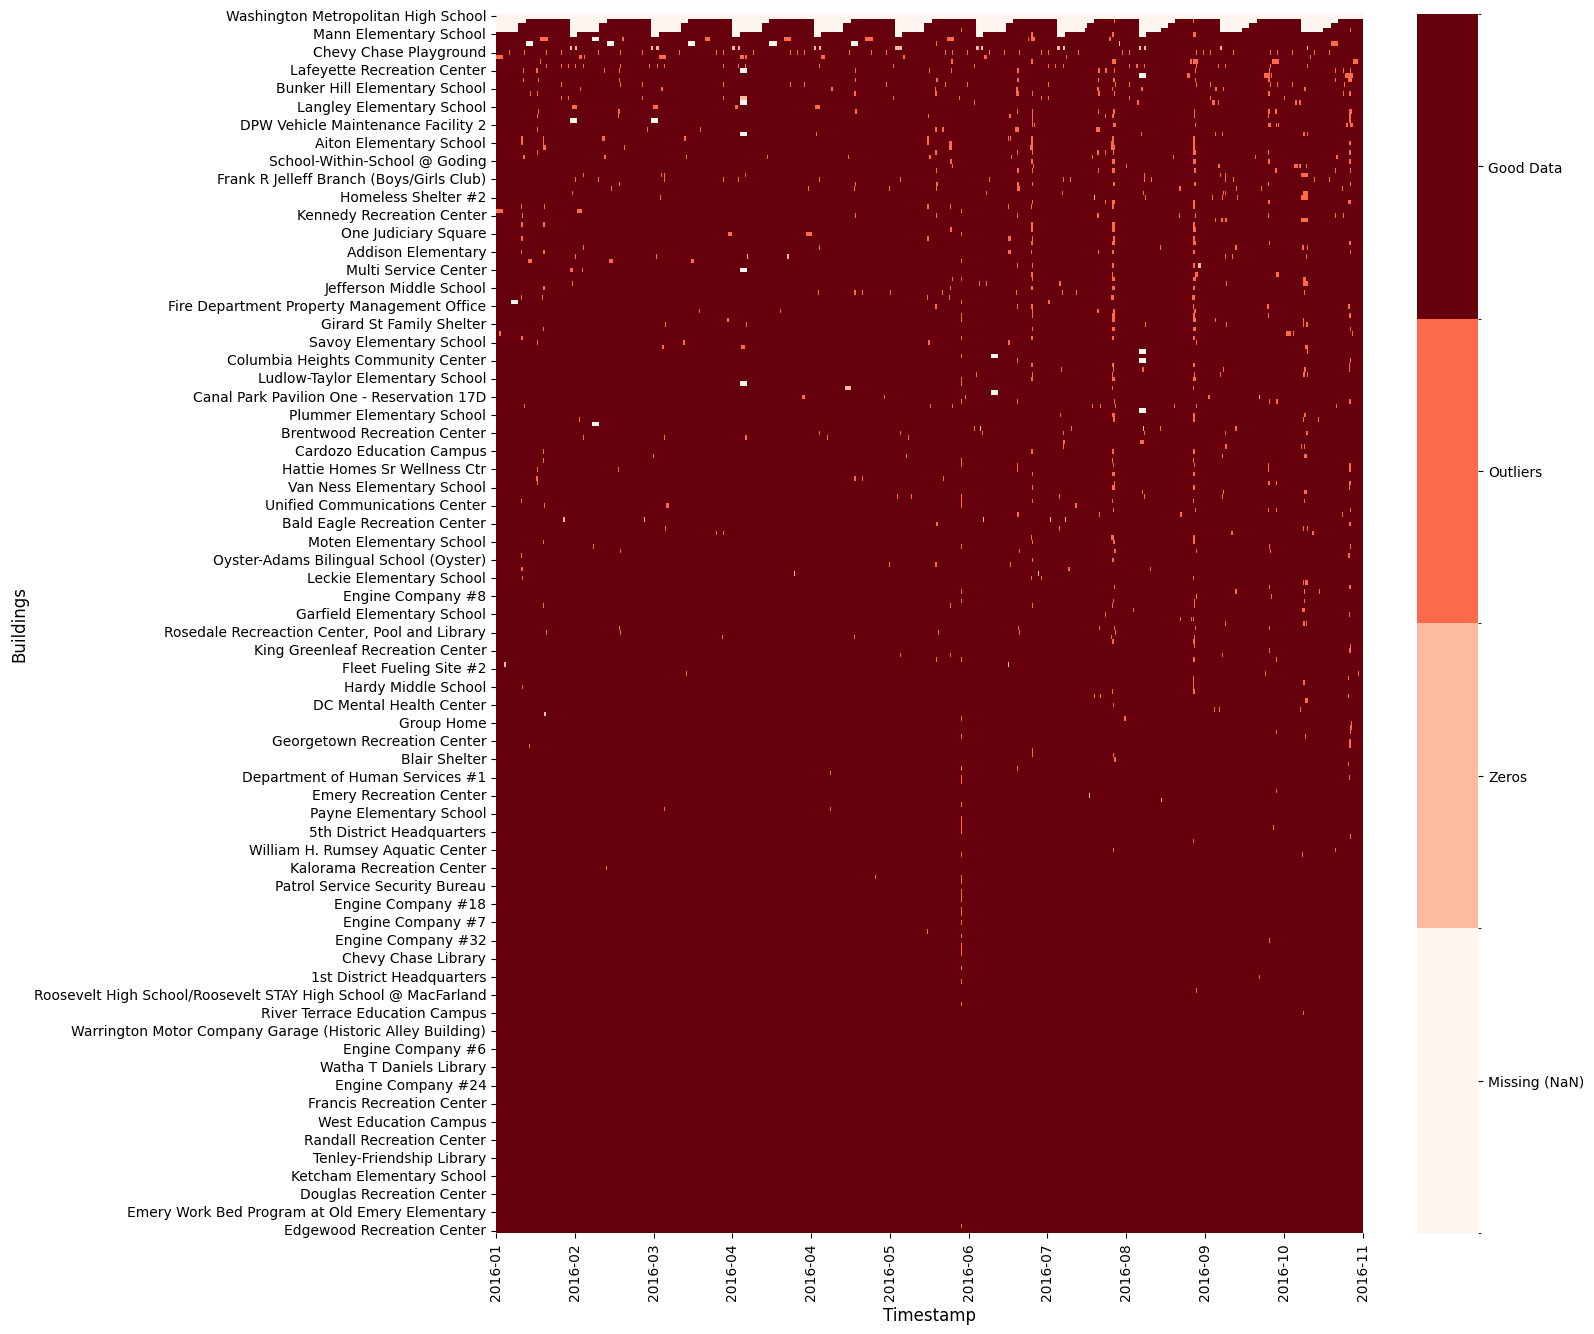

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

def plot_data_quality_heatmap(df, title=""):

    # 1. Create masks efficiently
    is_null = df.isna().values
    is_zero = (df == 0).values

    # Calculate outliers column-wise
    m = df.mean()
    s = df.std()
    is_outlier = ((df > m + 3*s) | (df < m - 3*s)).values

    # 2. Re-map numeric values (int8 saves RAM)
    # 0 = Missing, 1 = Zeros, 2 = Outliers, 3 = Good Data
    quality_grid = np.full(df.shape, 3, dtype=np.int8)
    quality_grid[is_null] = 0
    quality_grid[is_zero] = 1
    quality_grid[is_outlier] = 2

    # Create the quality DataFrame
    temp_quality_df = pd.DataFrame(quality_grid, index=df.index, columns=df.columns)

    # --- 3. ASCENDING SORT LOGIC ---
    # Count occurrences of '3' (Good Data) for each building
    good_data_counts = (temp_quality_df == 3).sum().sort_values(ascending=True)
    sorted_buildings = good_data_counts.index

    # Reorder the buildings: Least good data at the top (start of list), most at bottom
    plot_df = temp_quality_df[sorted_buildings].T

    # 4. SAFE VISUALIZATION LOGIC
    num_buildings = len(plot_df.index)
    dynamic_height = max(10, num_buildings * 0.05)
    dynamic_height = min(300, dynamic_height)

    print(f"Generating heatmap for {num_buildings} buildings...")
    plt.figure(figsize=(16, dynamic_height))

    colors = ["#fff5f0", "#fcbba1", "#fb6a4a", "#67000d"]
    cmap = mcolors.ListedColormap(colors)
    bounds = [0, 1, 2, 3, 4]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    # 5. Generate Heatmap
    ax = sns.heatmap(plot_df, cmap=cmap, norm=norm,
                     rasterized=True,
                     cbar_kws={
                         'label': '',
                         'ticks': [0.5, 1.5, 2.5, 3.5]
                     })

    # 6. Customize Legend
    colorbar = ax.collections[0].colorbar
    colorbar.set_ticklabels(['Missing (NaN)', 'Zeros', 'Outliers', 'Good Data'])

    # 7. Formatting
    plt.title("", fontsize=16, pad=20)
    plt.xlabel("Timestamp", fontsize=12)
    plt.ylabel("Buildings", fontsize=12)

    xticks = np.linspace(0, len(df.index) - 1, 12).astype(int)
    ax.set_xticks(xticks)
    ax.set_xticklabels(df.index[xticks].strftime('%Y-%m'), rotation=90)

    plt.tight_layout()

    output_path = 'DGS_data_quality_heatmap.png'
    plt.savefig(output_path, dpi=120, bbox_inches='tight')
    plt.show()
    plt.close()

if __name__ == '__main__':
    df_raw = pd.read_csv('/content/Electricity-hourly.csv', index_col='Timestamp', parse_dates=True)
    plot_data_quality_heatmap(df_raw)

In [ ]:
import pandas as pd
df = pd.read_csv('/content/Electricity-hourly.csv', index_col='Timestamp', parse_dates=True)
df.head()

,1st District Headquarters,DC Village,200 I Street Municipal Building,Fort Davis Recreation Center,Kimball Elementary School,Income Maintenance Administration Office,Washington Highlands Library,Leckie Elementary School,King Elementary School,Simon Elementary School,...,Ross Elementary School,Sasha Bruce Youthwork Inc,Shepard Park Library,Spring Road Community Support Services,Van Ness Elementary School,Washington Seniors Wellness Center,Waterfront Municipal Center East,Waterfront Municipal Center West,H.D. Woodson High School,Youth Services Administration #3
Timestamp,,,,,,,,,,,,,,,,,,,,,
2016-01-03 00:00:00,0.1273,0.4182,1.0834,0.0325,0.0426,0.0433,0.0349,0.0867,0.0573,0.0859,...,NaN,0.0182,0.0337,0.0268,0.0158,0.0183,0.2613,0.4746,0.2690,0.0280
2016-01-03 01:00:00,0.1265,0.4323,1.0368,0.0332,0.0426,0.0434,0.0356,0.0895,0.0573,0.0901,...,NaN,0.0149,0.0334,0.0268,0.0162,0.0185,0.2607,0.4821,0.2661,0.0278
2016-01-03 02:00:00,0.1259,0.4207,1.1288,0.0329,0.0420,0.0434,0.0361,0.0911,0.0572,0.0917,...,NaN,0.0152,0.0336,0.0265,0.0162,0.0191,0.2598,0.4828,0.2679,0.0274
2016-01-03 03:00:00,0.1241,0.4479,1.0382,0.0356,0.0414,0.0431,0.0364,0.0939,0.0582,0.0876,...,NaN,0.0186,0.0335,0.0275,0.0156,0.0191,0.2595,0.4866,0.2747,0.0269
2016-01-03 04:00:00,0.1218,0.4372,1.1129,0.0344,0.0415,0.0429,0.0358,0.1026,0.0665,0.0953,...,NaN,0.0145,0.0336,0.0264,0.0162,0.0198,0.2583,0.4880,0.3162,0.0275
